In [1]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from PIL import ImageFile
ImageFile.LOAD_TRUNCATED_IMAGES = True

C:\Users\pc\AppData\Local\Programs\Python\Python313\Lib\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/attr_value.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(
C:\Users\pc\AppData\Local\Programs\Python\Python313\Lib\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/tensor.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(
C:\Users\pc\AppData\Local\Programs\Python\Python313\Lib\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/resour

In [2]:
IMAGE_FOLDER = "D:\\Users\\pc\\Major Project\\ScienceDirect_articles_09Dec2025_15-34-30.660\\Images"
IMAGEWISE_CSV = "D:\\Users\\pc\\Major Project\\ScienceDirect_articles_09Dec2025_15-34-30.660\\Imagewise_Data.csv"
PATIENTWISE_CSV = "D:\\Users\\pc\\Major Project\\ScienceDirect_articles_09Dec2025_15-34-30.660\\Patientwise_Data.csv"

In [3]:
img_data = pd.read_csv(IMAGEWISE_CSV)
patient_data = pd.read_csv(PATIENTWISE_CSV)

print(img_data.head())
print(patient_data.head())

  Image Name Category Clinical Diagnosis  Lesion Annotation Count
0    R-01-01     OPMD        Leukoplakia                        1
1    R-01-02     OPMD        Leukoplakia                        1
2    R-01-03   Benign      Coated Tongue                        1
3    R-02-01   Benign                VBD                        1
4    R-02-02   Benign                VBD                        1
  Patient ID  Age Gender Smoking Chewing_Betel_Quid  Alcohol  Image Count
0       R-01   63      M      No                  No      No            3
1       R-02   17      F      No                  No      No            8
2       R-03   70      M      No                  No      No            5
3       R-04   45      M      No                  No      No            5
4       R-05   46      M      No                 Yes      No            2


In [6]:
#os.listdir(IMAGE_FOLDER)[:10]

In [7]:
def build_path(image_name):
    return os.path.join(IMAGE_FOLDER, image_name + ".jpg")
img_data['path'] = img_data['Image Name'].apply(build_path)
img_data.head()

,Image Name,Category,Clinical Diagnosis,Lesion Annotation Count,path
0,R-01-01,OPMD,Leukoplakia,1,D:\Users\pc\Major Project\ScienceDirect_articl...
1,R-01-02,OPMD,Leukoplakia,1,D:\Users\pc\Major Project\ScienceDirect_articl...
2,R-01-03,Benign,Coated Tongue,1,D:\Users\pc\Major Project\ScienceDirect_articl...
3,R-02-01,Benign,VBD,1,D:\Users\pc\Major Project\ScienceDirect_articl...
4,R-02-02,Benign,VBD,1,D:\Users\pc\Major Project\ScienceDirect_articl...


In [8]:
for p in img_data['path'].head():
    print(p, os.path.exists(p))

D:\Users\pc\Major Project\ScienceDirect_articles_09Dec2025_15-34-30.660\Images\R-01-01.jpg True
D:\Users\pc\Major Project\ScienceDirect_articles_09Dec2025_15-34-30.660\Images\R-01-02.jpg True
D:\Users\pc\Major Project\ScienceDirect_articles_09Dec2025_15-34-30.660\Images\R-01-03.jpg True
D:\Users\pc\Major Project\ScienceDirect_articles_09Dec2025_15-34-30.660\Images\R-02-01.jpg True
D:\Users\pc\Major Project\ScienceDirect_articles_09Dec2025_15-34-30.660\Images\R-02-02.jpg True


In [9]:
label_map = {
    "Healthy": 0,
    "Benign": 1,
    "OPMD": 2,
    "OCA": 3
}
img_data['label'] = img_data['Category'].map(label_map)
img_data['label'].value_counts()

label
2    1394
1     748
0     729
3     129
Name: count, dtype: int64

In [10]:
IMG_SIZE = 224
def preprocess_img(path):
    img = cv2.imread(path)
    if img is None:
        print("Missing:", path)
        return np.zeros((IMG_SIZE, IMG_SIZE, 3), dtype=np.float32)
    
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    img = cv2.GaussianBlur(img, (3,3), 0)
    
    img = img.astype(np.float32) / 255.0
    return img

In [11]:
from sklearn.utils import resample
class_majority = img_data[img_data['label'] != 3]      # all except OCA
class_minority = img_data[img_data['label'] == 3]      # OCA only

# Oversample minority
class_minority_upsampled = resample(
    class_minority,
    replace=True,          
    n_samples=400,         
    random_state=42
)
img_data_balanced = pd.concat([class_majority, class_minority_upsampled])
img_data_balanced = img_data_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

print("Balanced dataset size:", len(img_data_balanced))
print(img_data_balanced['label'].value_counts())

Balanced dataset size: 3271
label
2    1394
1     748
0     729
3     400
Name: count, dtype: int64


In [12]:
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(
    img_data_balanced,
    test_size=0.2,
    stratify=img_data_balanced['label'],
    random_state=42
)

print("Training samples:", len(train_df))
print("Testing samples:", len(test_df))

Training samples: 2616
Testing samples: 655


In [13]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = 224

train_gen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)

test_gen = ImageDataGenerator(rescale=1./255)

In [14]:
train_generator = train_gen.flow_from_dataframe(
    train_df,
    x_col="path",
    y_col="label",
    target_size=(IMG_SIZE, IMG_SIZE),
    class_mode="raw",
    batch_size=32,
    shuffle=True,
    validate_filenames=False
)

test_generator = test_gen.flow_from_dataframe(
    test_df,
    x_col="path",
    y_col="label",
    target_size=(IMG_SIZE, IMG_SIZE),
    class_mode="raw",
    batch_size=32,
    shuffle=False,
    validate_filenames=False
)

Found 2616 non-validated image filenames.
Found 655 non-validated image filenames.


In [15]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.models import Model

base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.3)(x)
output = Dense(4, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)

for layer in base_model.layers:
    layer.trainable = False   # freeze pretrained layers

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)    │ (None, 224, 224, 3)       │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ Conv1 (Conv2D)                │ (None, 112, 112, 32)      │             864 │ input_layer_1[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ bn_Conv1 (BatchNormalization) │ (None, 112, 112, 32)      │             128 │ Conv1[0][0]                │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ Conv1_relu (ReLU)             │ (None, 112, 112, 32)      │               0 │ bn_Conv1[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_depthwise       │ (None, 112, 112, 32)      │             288 │ Conv1_relu[0][0]           │
│ (DepthwiseConv2D)             │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_depthwise_BN    │ (None, 112, 112, 32)      │             128 │ expanded_conv_depthwise[0… │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_depthwise_relu  │ (None, 112, 112, 32)      │               0 │ expanded_conv_depthwise_B… │
│ (ReLU)                        │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_project         │ (None, 112, 112, 16)      │             512 │ expanded_conv_depthwise_r… │
│ (Conv2D)                      │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_project_BN      │ (None, 112, 112, 16)      │              64 │ expanded_conv_project[0][… │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_expand (Conv2D)       │ (None, 112, 112, 96)      │           1,536 │ expanded_conv_project_BN[… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_expand_BN             │ (None, 112, 112, 96)      │             384 │ block_1_expand[0][0]       │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_expand_relu (ReLU)    │ (None, 112, 112, 96)      │               0 │ block_1_expand_BN[0][0]    │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_pad (ZeroPadding2D)   │ (None, 113, 113, 96)      │               0 │ block_1_expand_relu[0][0]  │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_depthwise             │ (None, 56, 56, 96)        │             864 │ block_1_pad[0][0]          │
│ (DepthwiseConv2D)             │                           │               

 Total params: 2,263,108 (8.63 MB)

 Trainable params: 5,124 (20.02 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [16]:
history = model.fit(
    train_generator,
    validation_data=test_generator,
    epochs=12
)

C:\Users\pc\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/12
82/82 ━━━━━━━━━━━━━━━━━━━━ 241s 3s/step - accuracy: 0.3777 - loss: 1.5547 - val_accuracy: 0.3954 - val_loss: 1.2778
Epoch 2/12
82/82 ━━━━━━━━━━━━━━━━━━━━ 230s 3s/step - accuracy: 0.4415 - loss: 1.3074 - val_accuracy: 0.4641 - val_loss: 1.1585
Epoch 3/12
82/82 ━━━━━━━━━━━━━━━━━━━━ 227s 3s/step - accuracy: 0.5027 - loss: 1.1570 - val_accuracy: 0.4962 - val_loss: 1.1010
Epoch 4/12
82/82 ━━━━━━━━━━━━━━━━━━━━ 227s 3s/step - accuracy: 0.5088 - loss: 1.1249 - val_accuracy: 0.4672 - val_loss: 1.1271
Epoch 5/12
82/82 ━━━━━━━━━━━━━━━━━━━━ 228s 3s/step - accuracy: 0.5356 - loss: 1.0850 - val_accuracy: 0.4794 - val_loss: 1.1517
Epoch 6/12
82/82 ━━━━━━━━━━━━━━━━━━━━ 227s 3s/step - accuracy: 0.5508 - loss: 1.0572 - val_accuracy: 0.5145 - val_loss: 1.0779
Epoch 7/12
82/82 ━━━━━━━━━━━━━━━━━━━━ 231s 3s/step - accuracy: 0.5554 - loss: 1.0288 - val_accuracy: 0.5267 - val_loss: 1.0541
Epoch 8/12
82/82 ━━━━━━━━━━━━━━━━━━━━ 228s 3s/step - accuracy: 0.5596 - loss: 1.0145 - val_accuracy: 0.5344 - v

In [17]:
for layer in base_model.layers[-40:]:
    layer.trainable = True

In [18]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [19]:
history_ft = model.fit(
    train_generator,
    validation_data=test_generator,
    epochs=10
)

Epoch 1/10
82/82 ━━━━━━━━━━━━━━━━━━━━ 264s 3s/step - accuracy: 0.4736 - loss: 1.2299 - val_accuracy: 0.5450 - val_loss: 1.0246
Epoch 2/10
82/82 ━━━━━━━━━━━━━━━━━━━━ 249s 3s/step - accuracy: 0.5291 - loss: 1.1014 - val_accuracy: 0.5496 - val_loss: 1.0315
Epoch 3/10
82/82 ━━━━━━━━━━━━━━━━━━━━ 252s 3s/step - accuracy: 0.5677 - loss: 1.0283 - val_accuracy: 0.5405 - val_loss: 1.0412
Epoch 4/10
82/82 ━━━━━━━━━━━━━━━━━━━━ 248s 3s/step - accuracy: 0.5707 - loss: 1.0279 - val_accuracy: 0.5405 - val_loss: 1.0466
Epoch 5/10
82/82 ━━━━━━━━━━━━━━━━━━━━ 251s 3s/step - accuracy: 0.5914 - loss: 0.9793 - val_accuracy: 0.5389 - val_loss: 1.0505
Epoch 6/10
82/82 ━━━━━━━━━━━━━━━━━━━━ 252s 3s/step - accuracy: 0.6097 - loss: 0.9434 - val_accuracy: 0.5328 - val_loss: 1.0369
Epoch 7/10
82/82 ━━━━━━━━━━━━━━━━━━━━ 248s 3s/step - accuracy: 0.5994 - loss: 0.9391 - val_accuracy: 0.5405 - val_loss: 1.0284
Epoch 8/10
82/82 ━━━━━━━━━━━━━━━━━━━━ 252s 3s/step - accuracy: 0.6273 - loss: 0.8988 - val_accuracy: 0.5481 - v

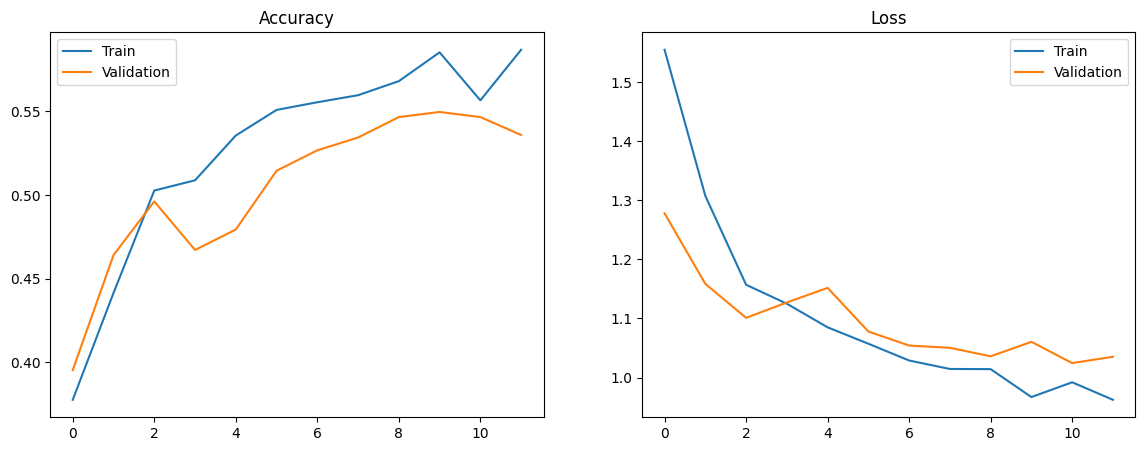

In [20]:
plt.figure(figsize=(14,5))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.title("Accuracy")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Validation')
plt.title("Loss")
plt.legend()

plt.show()

21/21 ━━━━━━━━━━━━━━━━━━━━ 45s 2s/step 


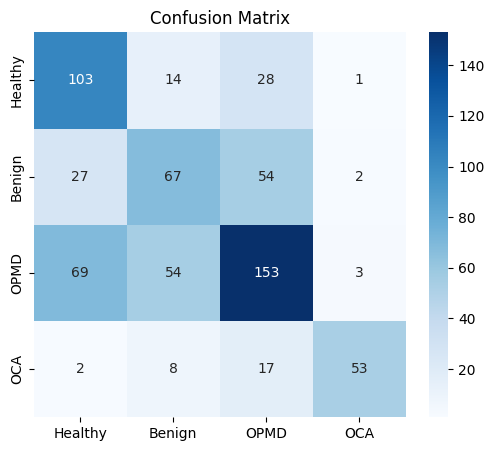

              precision    recall  f1-score   support

           0       0.51      0.71      0.59       146
           1       0.47      0.45      0.46       150
           2       0.61      0.55      0.58       279
           3       0.90      0.66      0.76        80

    accuracy                           0.57       655
   macro avg       0.62      0.59      0.60       655
weighted avg       0.59      0.57      0.58       655



In [21]:
y_pred = np.argmax(model.predict(test_generator), axis=1)
y_true = test_df['label'].values

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_map.keys(),
            yticklabels=label_map.keys())
plt.title("Confusion Matrix")
plt.show()

print(classification_report(y_true, y_pred))

In [22]:
def risk_score(tobacco, betel, alcohol):
    score = (tobacco * 0.4) + (betel * 0.4) + (alcohol * 0.2)
    
    if score >= 0.7:
        return "High Risk"
    elif score >= 0.3:
        return "Moderate Risk"
    else:
        return "Low Risk"

In [23]:
inv_label_map = {v:k for k,v in label_map.items()}

def predict_full(image_path, tobacco=0, betel=0, alcohol=0):
    img = preprocess_img(image_path).reshape(1, IMG_SIZE, IMG_SIZE, 3)
    pred = model.predict(img)[0]
    class_id = np.argmax(pred)
    class_name = inv_label_map[class_id]
    confidence = float(pred[class_id])
    risk = risk_score(tobacco, betel, alcohol)
    if class_name == "OCA":  
        final_msg = "Cancer detected — immediate specialist referral required." 
    elif class_name == "OPMD":
        if risk == "High Risk":
            final_msg = "Pre-malignant lesion detected & lifestyle risk is HIGH — urgent clinical evaluation needed."
        else:
            final_msg = "OPMD detected — schedule diagnostic screening."
    elif class_name == "Benign":
        if risk == "High Risk":
            final_msg = "Benign lesion but lifestyle risk is high — monitor regularly and reduce habits."
        else:
            final_msg = "Benign lesion — routine oral care recommended."
    elif class_name == "Healthy":
        if risk == "High Risk":
            final_msg = "Healthy mouth but high lifestyle risk — preventive counseling advised."
        else:
            final_msg = "Healthy mouth — low risk."
    print("Image Prediction:", class_name)
    print("Confidence:", round(confidence, 3))
    print("Lifestyle Risk:", risk)
    print("Final Recommendation:", final_msg)
    return class_name, pred, risk, final_msg

In [24]:
sample_path = test_df['path'].iloc[0]
predict_full(sample_path, tobacco=1, betel=1, alcohol=0)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 831ms/step
Image Prediction: Healthy
Confidence: 0.661
Lifestyle Risk: High Risk
Final Recommendation: Healthy mouth but high lifestyle risk — preventive counseling advised.


('Healthy',
 array([6.6143143e-01, 4.9930699e-02, 2.8808606e-01, 5.5181445e-04],
       dtype=float32),
 'High Risk',
 'Healthy mouth but high lifestyle risk — preventive counseling advised.')

In [25]:
model.save("oral_cancer_model.keras")

## Model Improvement using DenseNet121 (Transfer Learning)


In the initial phase of this project, MobileNetV2 was used as the base CNN model for oral cancer image classification. 
Although MobileNetV2 is lightweight and fast, the achieved validation accuracy (~58%) was not satisfactory for a medical diagnostic application, where higher accuracy and better class discrimination are critical.

To improve the model performance, a more powerful deep learning architecture was required.
Hence, DenseNet121 was introduced as an alternative transfer learning model.


DenseNet121 is a deep convolutional neural network that uses dense connections between layers. 
Each layer receives feature maps from all previous layers, which helps in:
- Better feature reuse
- Strong gradient flow
- Reduced overfitting on small datasets
- Improved learning of fine-grained patterns in medical images

DenseNet architectures have been widely used in medical image analysis tasks such as cancer detection, X-ray classification, and histopathology image recognition.
Therefore, DenseNet121 was selected to enhance the classification performance of oral lesion images.


The DenseNet121 model pre-trained on ImageNet was used as the base model with the top classification layers removed.
A custom classification head consisting of:
- Global Average Pooling
- Fully connected Dense layer
- Dropout layers for regularization
- Softmax output layer for multi-class classification

was added on top of DenseNet121.

Initially, the base model layers were frozen to train only the newly added layers.
After initial training, fine-tuning was performed by unfreezing the last few layers of DenseNet121 with a lower learning rate to further improve performance.


By replacing MobileNetV2 with DenseNet121, the model is expected to:
- Achieve higher validation accuracy
- Improve recall and precision for the Oral Cancer (OCA) class
- Learn more discriminative features from lesion images
- Provide more reliable predictions for clinical decision support


This experiment demonstrates the importance of model selection in deep learning and shows how transfer learning with different architectures can significantly affect performance.

It also highlights a comparative study approach, where multiple CNN models are tested and evaluated to determine the best performing model for a given medical imaging problem.


In [26]:
# DenseNet121 Model (New Experiment)

from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

IMG_SIZE = 224
NUM_CLASSES = 4

# Build DenseNet121 base model
base_model_dn = DenseNet121(
    weights="imagenet",
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

# Freeze base model layers
for layer in base_model_dn.layers:
    layer.trainable = False

x = base_model_dn.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.4)(x)
x = Dense(256, activation="relu")(x)
x = Dropout(0.3)(x)
output = Dense(NUM_CLASSES, activation="softmax")(x)

dense_model = Model(inputs=base_model_dn.input, outputs=output)

dense_model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

dense_model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)    │ (None, 224, 224, 3)       │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ zero_padding2d_2              │ (None, 230, 230, 3)       │               0 │ input_layer_2[0][0]        │
│ (ZeroPadding2D)               │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1_conv (Conv2D)           │ (None, 112, 112, 64)      │           9,408 │ zero_padding2d_2[0][0]     │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1_bn (BatchNormalization) │ (None, 112, 112, 64)      │             256 │ conv1_conv[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1_relu (Activation)       │ (None, 112, 112, 64)      │               0 │ conv1_bn[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ zero_padding2d_3              │ (None, 114, 114, 64)      │               0 │ conv1_relu[0][0]           │
│ (ZeroPadding2D)               │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ pool1 (MaxPooling2D)          │ (None, 56, 56, 64)        │               0 │ zero_padding2d_3[0][0]     │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_0_bn             │ (None, 56, 56, 64)        │             256 │ pool1[0][0]                │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_0_relu           │ (None, 56, 56, 64)        │               0 │ conv2_block1_0_bn[0][0]    │
│ (Activation)                  │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_1_conv (Conv2D)  │ (None, 56, 56, 128)       │           8,192 │ conv2_block1_0_relu[0][0]  │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_1_bn             │ (None, 56, 56, 128)       │             512 │ conv2_block1_1_conv[0][0]  │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_1_relu           │ (None, 56, 56, 128)       │               0 │ conv2_block1_1_bn[0][0]    │
│ (Activation)                  │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_2_conv (Conv2D)  │ (None, 56, 56, 32)        │          36,864 │ conv2_block1_1_relu[0][0]  │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_concat           │ (None, 56, 56, 96)        │               0 │ pool1[0][0],               │
│ (Concatenate)                 │                           │               

 Total params: 7,300,932 (27.85 MB)

 Trainable params: 263,428 (1.00 MB)

 Non-trainable params: 7,037,504 (26.85 MB)

In [27]:
callbacks_dn = [
    EarlyStopping(patience=6, restore_best_weights=True),
    ReduceLROnPlateau(patience=3, factor=0.3),
    ModelCheckpoint("best_dense_oral_cancer.keras", save_best_only=True)
]

history_dn = dense_model.fit(
    train_generator,
    validation_data=test_generator,
    epochs=30,
    callbacks=callbacks_dn
)

Epoch 1/30
82/82 ━━━━━━━━━━━━━━━━━━━━ 362s 4s/step - accuracy: 0.3330 - loss: 1.7502 - val_accuracy: 0.4168 - val_loss: 1.3463 - learning_rate: 1.0000e-04
Epoch 2/30
82/82 ━━━━━━━━━━━━━━━━━━━━ 342s 4s/step - accuracy: 0.3586 - loss: 1.5423 - val_accuracy: 0.4153 - val_loss: 1.2667 - learning_rate: 1.0000e-04
Epoch 3/30
82/82 ━━━━━━━━━━━━━━━━━━━━ 340s 4s/step - accuracy: 0.4018 - loss: 1.4164 - val_accuracy: 0.4504 - val_loss: 1.2236 - learning_rate: 1.0000e-04
Epoch 4/30
82/82 ━━━━━━━━━━━━━━━━━━━━ 343s 4s/step - accuracy: 0.4121 - loss: 1.3338 - val_accuracy: 0.4534 - val_loss: 1.2137 - learning_rate: 1.0000e-04
Epoch 5/30
82/82 ━━━━━━━━━━━━━━━━━━━━ 340s 4s/step - accuracy: 0.4197 - loss: 1.3086 - val_accuracy: 0.4702 - val_loss: 1.1914 - learning_rate: 1.0000e-04
Epoch 6/30
82/82 ━━━━━━━━━━━━━━━━━━━━ 347s 4s/step - accuracy: 0.4373 - loss: 1.2948 - val_accuracy: 0.4855 - val_loss: 1.1885 - learning_rate: 1.0000e-04
Epoch 7/30
82/82 ━━━━━━━━━━━━━━━━━━━━ 342s 4s/step - accuracy: 0.4339 

In [28]:
# Unfreeze last 40 layers
for layer in base_model_dn.layers[-40:]:
    layer.trainable = True

dense_model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history_dn_ft = dense_model.fit(
    train_generator,
    validation_data=test_generator,
    epochs=15,
    callbacks=callbacks_dn
)

Epoch 1/15
82/82 ━━━━━━━━━━━━━━━━━━━━ 385s 5s/step - accuracy: 0.4912 - loss: 1.1448 - val_accuracy: 0.5420 - val_loss: 1.0784 - learning_rate: 1.0000e-05
Epoch 2/15
82/82 ━━━━━━━━━━━━━━━━━━━━ 363s 4s/step - accuracy: 0.5008 - loss: 1.1148 - val_accuracy: 0.5435 - val_loss: 1.0730 - learning_rate: 1.0000e-05
Epoch 3/15
82/82 ━━━━━━━━━━━━━━━━━━━━ 361s 4s/step - accuracy: 0.4996 - loss: 1.1221 - val_accuracy: 0.5450 - val_loss: 1.0682 - learning_rate: 1.0000e-05
Epoch 4/15
82/82 ━━━━━━━━━━━━━━━━━━━━ 358s 4s/step - accuracy: 0.5126 - loss: 1.0960 - val_accuracy: 0.5527 - val_loss: 1.0622 - learning_rate: 1.0000e-05
Epoch 5/15
82/82 ━━━━━━━━━━━━━━━━━━━━ 360s 4s/step - accuracy: 0.5119 - loss: 1.0923 - val_accuracy: 0.5511 - val_loss: 1.0586 - learning_rate: 1.0000e-05
Epoch 6/15
82/82 ━━━━━━━━━━━━━━━━━━━━ 364s 4s/step - accuracy: 0.5103 - loss: 1.0950 - val_accuracy: 0.5603 - val_loss: 1.0539 - learning_rate: 1.0000e-05
Epoch 7/15
82/82 ━━━━━━━━━━━━━━━━━━━━ 359s 4s/step - accuracy: 0.5103 

21/21 ━━━━━━━━━━━━━━━━━━━━ 72s 3s/step 


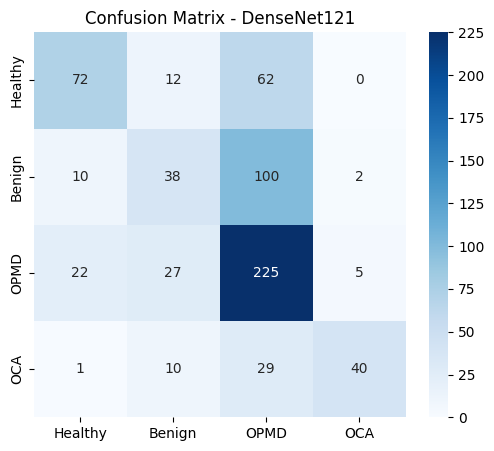

Classification Report - DenseNet121
              precision    recall  f1-score   support

           0       0.69      0.49      0.57       146
           1       0.44      0.25      0.32       150
           2       0.54      0.81      0.65       279
           3       0.85      0.50      0.63        80

    accuracy                           0.57       655
   macro avg       0.63      0.51      0.54       655
weighted avg       0.59      0.57      0.55       655



In [29]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

y_pred_dn = np.argmax(dense_model.predict(test_generator), axis=1)
y_true = test_df['label'].values

cm_dn = confusion_matrix(y_true, y_pred_dn)

plt.figure(figsize=(6,5))
sns.heatmap(cm_dn, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_map.keys(),
            yticklabels=label_map.keys())
plt.title("Confusion Matrix - DenseNet121")
plt.show()

print("Classification Report - DenseNet121")
print(classification_report(y_true, y_pred_dn))

In [30]:
dense_model.save("oral_cancer_densenet121.keras")

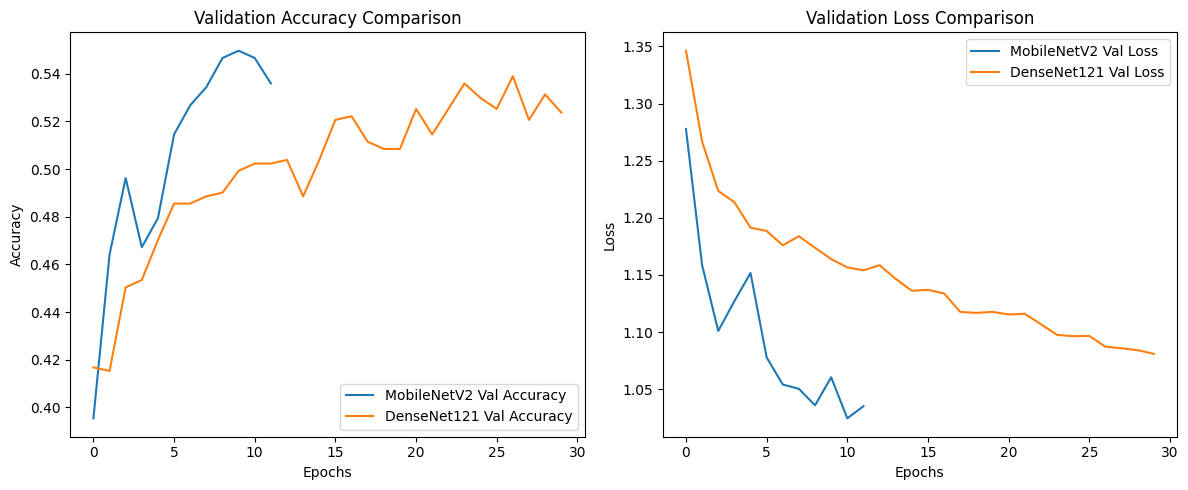

In [31]:
import matplotlib.pyplot as plt

# Accuracy comparison
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['val_accuracy'], label='MobileNetV2 Val Accuracy')
plt.plot(history_dn.history['val_accuracy'], label='DenseNet121 Val Accuracy')
plt.title("Validation Accuracy Comparison")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()

# Loss comparison
plt.subplot(1,2,2)
plt.plot(history.history['val_loss'], label='MobileNetV2 Val Loss')
plt.plot(history_dn.history['val_loss'], label='DenseNet121 Val Loss')
plt.title("Validation Loss Comparison")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()

The comparison shows that MobileNetV2 converges faster in early epochs due to its lightweight architecture, 
while DenseNet121 demonstrates more stable learning with gradual improvement over longer training duration.

Although the accuracy improvement is moderate, DenseNet121 provides better generalization and learning stability, 
which is crucial for medical image classification tasks. This experiment highlights the impact of model depth 
and architecture on performance.
